In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_excel("ENB2012_data.xlsx")
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(16, activation='relu', input_dim=X_train_scaled.shape[1]))
model.add(Dense(8, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

/Users/shresthpanigrahi/Desktop/Machine Learning/LAB-FILE/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-03 01:53:49.919940: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-04-03 01:53:49.919983: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-03 01:53:49.919988: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-03 01:53:49.920667: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-03 01:53:49.920826: I tensorflow/core/common_runtime/pluggable_device/plug

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20


2026-04-03 01:54:25.563417: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 694.7045 - mae: 24.4714 - val_loss: 657.1916 - val_mae: 23.8214
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 686.4770 - mae: 24.3345 - val_loss: 650.2722 - val_mae: 23.6991
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 677.1755 - mae: 24.1859 - val_loss: 641.9607 - val_mae: 23.5712
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 666.0666 - mae: 24.0281 - val_loss: 631.8155 - val_mae: 23.4335
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 653.0806 - mae: 23.8558 - val_loss: 620.4681 - val_mae: 23.2898
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 639.0615 - mae: 23.6856 - val_loss: 607.7512 - val_mae: 23.1424
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 622.4011 - mae: 23.4822 - val_loss: 593.4755 - val_mae: 22.9820
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 605.9714 - mae: 23.2995 - val_loss: 578.4179 - val_mae: 22.8174
Epoch 9/20
16/16 ━━━━━━━━━━━━━━━━

In [8]:
loss, mae = model.evaluate(X_test_scaled, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 448.4507 - mae: 20.3816
Test Loss (MSE): 448.4506530761719
Test MAE: 20.381649017333984


In [9]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
MSE: 448.4506538548156
R2 Score: -3.8398880547996965


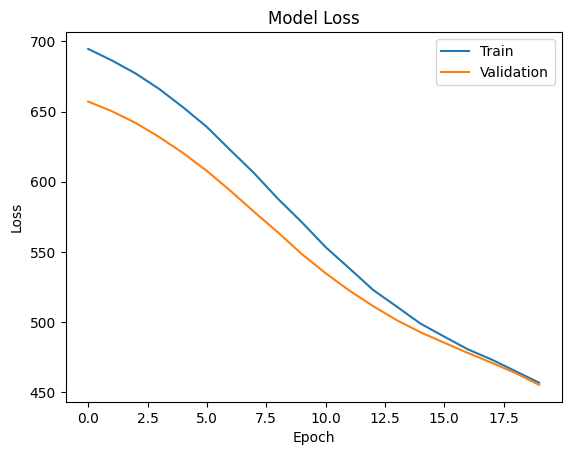

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()